# Projet Attrition RH - Partie 1 : Exploration & Préprocessing

**Auteur de cette partie : Mohammed MOSLEH**
Projet de groupe (Mohammed MOSLEH & Chaimae IMRANI).

But du projet : prédire si un employé va quitter l'entreprise (`Attrition` Yes/No),
pour aider le service RH à cibler ses actions de rétention.

Ce notebook fait tout le travail de **données** (J1 + J2) : explorer, nettoyer, encoder,
chasser la multicolinéarité, trier les features. En sortie : un dataset propre et 100%
numérique que la **Partie 2 (Chaimae)** utilisera pour la modélisation et le déploiement.

## Phase 1 : Charger et auditer la donnée

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/HR-Employee-Attrition.csv")
print("Forme :", df.shape)
df.head()

Forme : (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [2]:
def audit_qualite(df, cible="Attrition"):
    """Rapport de sante : forme, manquants, equilibre de la cible."""
    print("Forme :", df.shape)
    manquants = df.isna().sum()
    manquants = manquants[manquants > 0]
    print("Colonnes avec manquants :", "aucune" if len(manquants) == 0 else manquants.to_dict())
    print(f"\nRepartition de la cible '{cible}' :")
    counts = df[cible].value_counts()
    for v, n in counts.items():
        print(f"  {v} : {n} ({100*n/len(df):.1f}%)")

audit_qualite(df)
print("\n-> Cible desequilibree (~16% de departs) : l'accuracy seule sera trompeuse,")
print("   on devra surveiller le recall sur les partants (ce sera le coeur de la Partie 2).")

Forme : (1470, 35)
Colonnes avec manquants : aucune

Repartition de la cible 'Attrition' :
  No : 1233 (83.9%)
  Yes : 237 (16.1%)

-> Cible desequilibree (~16% de departs) : l'accuracy seule sera trompeuse,
   on devra surveiller le recall sur les partants (ce sera le coeur de la Partie 2).


## Phase 2 : Explorer un peu

On regarde quelques signaux métier avant de nettoyer.

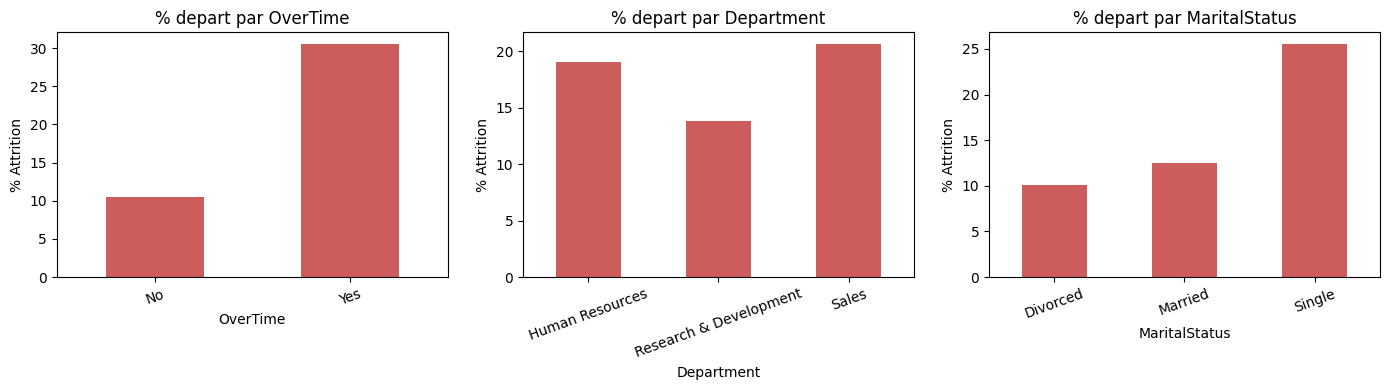

Lecture metier : les employes en heures supplementaires (OverTime) partent beaucoup plus.


In [3]:
# Taux de depart selon quelques variables parlantes
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["OverTime", "Department", "MaritalStatus"]):
    taux = df.groupby(col)["Attrition"].apply(lambda s: (s == "Yes").mean() * 100)
    taux.plot(kind="bar", ax=ax, color="indianred")
    ax.set_title(f"% depart par {col}"); ax.set_ylabel("% Attrition"); ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

print("Lecture metier : les employes en heures supplementaires (OverTime) partent beaucoup plus.")

## Phase 3 : Nettoyer les colonnes inutiles

Certaines colonnes ne servent à rien : elles sont **constantes** (même valeur partout)
ou ce sont des **identifiants**. On les supprime.

In [4]:
# Colonnes constantes (un seul niveau) + identifiant
constantes = [c for c in df.columns if df[c].nunique() == 1]
print("Colonnes constantes detectees :", constantes)

a_jeter = constantes + ["EmployeeNumber"]   # EmployeeNumber = identifiant, pas une feature
df = df.drop(columns=a_jeter)
print("Colonnes supprimees :", a_jeter)
print("Forme apres nettoyage :", df.shape)

Colonnes constantes detectees : ['EmployeeCount', 'Over18', 'StandardHours']
Colonnes supprimees : ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
Forme apres nettoyage : (1470, 31)


## Phase 4 : Encoder les catégorielles

Un modèle ne lit que des nombres. On encode :
- la cible et les binaires (Yes/No, Gender, OverTime) → 0/1
- les nominales (Department, JobRole, BusinessTravel...) → One-Hot.

In [5]:
def encoder(df, cible="Attrition"):
    """Encode toutes les categorielles, renvoie un df 100% numerique."""
    df = df.copy()
    # Cible : Yes = 1 (l'employe part), No = 0
    df[cible] = (df[cible] == "Yes").astype(int)

    # Binaires evidentes
    df["OverTime"] = (df["OverTime"] == "Yes").astype(int)
    df["Gender"] = (df["Gender"] == "Male").astype(int)   # 1 = Male, 0 = Female

    # Le reste des colonnes texte -> One-Hot
    cols_texte = df.select_dtypes(include="object").columns.tolist()
    df = pd.get_dummies(df, columns=cols_texte, drop_first=False)
    df = df.astype({c: int for c in df.select_dtypes(include="bool").columns})
    return df

df_enc = encoder(df)
print("Colonnes apres encodage :", df_enc.shape[1], "(toutes numeriques)")
print("Reste-t-il du texte ?", "non" if df_enc.select_dtypes(include="object").empty else "oui")

Colonnes apres encodage : 50 (toutes numeriques)
Reste-t-il du texte ? non


C:\Users\mosle\AppData\Local\Temp\ipykernel_15836\3358019822.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_texte = df.select_dtypes(include="object").columns.tolist()


## Phase 5 : Outliers et multicolinéarité

On regarde les variables d'ancienneté, souvent redondantes (rester longtemps dans
l'entreprise, dans son poste, avec son manager... ça bouge ensemble).

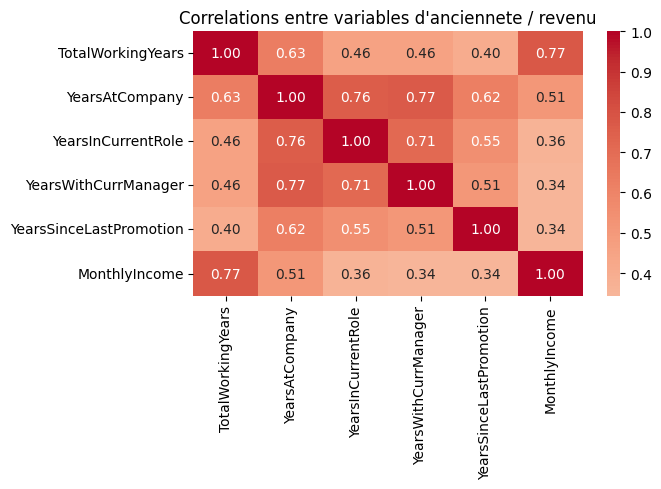

In [6]:
# Heatmap des correlations sur quelques variables d'anciennete
anc = ["TotalWorkingYears", "YearsAtCompany", "YearsInCurrentRole",
       "YearsWithCurrManager", "YearsSinceLastPromotion", "MonthlyIncome"]
plt.figure(figsize=(7, 5))
sns.heatmap(df[anc].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlations entre variables d'anciennete / revenu")
plt.tight_layout(); plt.show()

In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def vif_table(df, cols):
    X = df[cols].dropna().values
    return pd.DataFrame({"variable": cols,
                         "VIF": [variance_inflation_factor(X, i) for i in range(len(cols))]})

vif = vif_table(df, anc)
print(vif.round(1).to_string(index=False))
print("\nVIF eleve = redondance. YearsAtCompany resume deja une bonne partie des autres.")
print("On retire YearsInCurrentRole et YearsWithCurrManager (tres correlees) pour stabiliser.")

               variable  VIF
      TotalWorkingYears  9.0
         YearsAtCompany  9.7
     YearsInCurrentRole  6.1
   YearsWithCurrManager  6.2
YearsSinceLastPromotion  2.4
          MonthlyIncome  6.9

VIF eleve = redondance. YearsAtCompany resume deja une bonne partie des autres.
On retire YearsInCurrentRole et YearsWithCurrManager (tres correlees) pour stabiliser.


In [8]:
# On supprime les deux variables les plus redondantes de la version encodee
a_retirer = ["YearsInCurrentRole", "YearsWithCurrManager"]
df_enc = df_enc.drop(columns=[c for c in a_retirer if c in df_enc.columns])
print("Retirees :", a_retirer)
print("Forme finale encodee :", df_enc.shape)

Retirees : ['YearsInCurrentRole', 'YearsWithCurrManager']
Forme finale encodee : (1470, 48)


## Phase 6 : Les variables qui prédisent vraiment le départ

On croise deux approches : corrélation à la cible et importance d'un Random Forest.

In [9]:
from sklearn.ensemble import RandomForestClassifier

X = df_enc.drop(columns="Attrition")
y = df_enc["Attrition"]

# Approche 1 : correlation a la cible
corr = df_enc.corr()["Attrition"].drop("Attrition").abs().sort_values(ascending=False)

# Approche 2 : importance Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42).fit(X, y)
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Top 8 - correlation a la cible :")
print(corr.head(8).round(3).to_string())
print("\nTop 8 - importance Random Forest :")
print(imp.head(8).round(3).to_string())
print("\nHistoire metier : OverTime, MonthlyIncome, Age et l'anciennete dominent.")
print("Les jeunes, mal payes et en heures sup' sont les plus a risque de partir.")

Top 8 - correlation a la cible :
OverTime                        0.246
MaritalStatus_Single            0.175
TotalWorkingYears               0.171
JobLevel                        0.169
MonthlyIncome                   0.160
Age                             0.159
JobRole_Sales Representative    0.157
StockOptionLevel                0.137

Top 8 - importance Random Forest :
MonthlyIncome        0.072
Age                  0.059
TotalWorkingYears    0.056
DailyRate            0.055
YearsAtCompany       0.052
OverTime             0.052
MonthlyRate          0.049
HourlyRate           0.049

Histoire metier : OverTime, MonthlyIncome, Age et l'anciennete dominent.
Les jeunes, mal payes et en heures sup' sont les plus a risque de partir.


## Sauvegarde pour la Partie 2

On exporte le dataset propre et encodé. C'est le **carburant** du notebook de Chaimae
(modélisation, évaluation, déploiement).

In [10]:
df_enc.to_csv("data/attrition_clean.csv", index=False)
print("Dataset propre sauvegarde : data/attrition_clean.csv")
print("Forme :", df_enc.shape, "| cible 'Attrition' incluse (1 = part, 0 = reste)")

Dataset propre sauvegarde : data/attrition_clean.csv
Forme : (1470, 48) | cible 'Attrition' incluse (1 = part, 0 = reste)


---
### Bilan Partie 1

Données brutes (1470 × 35) nettoyées : colonnes constantes et identifiant supprimés,
catégorielles encodées, variables redondantes retirées (VIF), features prédictives
identifiées. Le dataset est propre, 100% numérique, prêt pour l'Arène des algos.

➡️ La suite dans **02_modelisation_evaluation.ipynb** (Chaimae IMRANI).